In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
import os

%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

os.makedirs('../figures', exist_ok=True)

In [ ]:
# Parametres fixes pour toute l'etude
p   = 32       # points de grille spatiale
N   = 3        # frequences de Fourier
d   = 2*N + 1  # dimension du signal
n_z = 64       # points de quadrature 

xgrid = np.linspace(0, 2*np.pi, p,   endpoint=False)
zgrid = np.linspace(0, 2*np.pi, n_z, endpoint=False)

# Vrai parametre : fixé une fois pour toutes les experiences
np.random.seed(43)
u_true = np.random.randn(d)
print('u_true =', np.round(u_true, 3))

u_true = [ 0.257 -0.908 -0.379 -0.535  0.858 -0.413  0.498]


In [ ]:
#  Matrice d'evaluation

def build_phi(z):
    """Matrice Phi(z) de taille (p, d)."""
    phi = np.zeros((p, d))
    phi[:, 0] = 1.0
    for k in range(1, N + 1):
        phi[:, 2*k - 1] = np.cos(k * (xgrid - z))
        phi[:, 2*k]     = np.sin(k * (xgrid - z))
    return phi  # (p, d)

def build_phiu(z, u):
    """Signal theta_u sur la grille, pour le decalage z."""
    return build_phi(z) @ u

# Precalcul une seule fois sur la grille de quadrature
Phi_stack     = np.array([build_phi(z) for z in zgrid])          # (n_z, p, d)
PhiTPhi_stack = np.einsum('qpi,qpj->qij', Phi_stack, Phi_stack)  # (n_z, d, d)
print(f'Phi_stack : {Phi_stack.shape}   PhiTPhi_stack : {PhiTPhi_stack.shape}')

Phi_stack : (64, 32, 7)   PhiTPhi_stack : (64, 7, 7)


In [ ]:
# Algorithme EM 

def e_step(u, observations, sigma):
    """
    Etape E
    """
    Amu       = Phi_stack @ u                                      # (n_z, p)
    residuals = observations[:, np.newaxis, :] - Amu[np.newaxis]  # (n, n_z, p)
    log_w     = -0.5 / sigma**2 * np.sum(residuals**2, axis=2)    # (n, n_z)
    log_w     = np.clip(log_w, -745.0, None)
    # Stabilisation : soustraction du max par ligne avant softmax
    log_w    -= log_w.max(axis=1, keepdims=True)
    w         = np.exp(log_w)
    return w / w.sum(axis=1, keepdims=True)                        # (n, n_z)


def m_step(weights, observations):
    """
    Etape M
    """
    w_sum_i = weights.sum(axis=0)                                        # (n_z,)
    M_mat   = np.einsum('q,qij->ij', w_sum_i, PhiTPhi_stack)            # (d, d)
    wY      = np.einsum('iq,ip->qp', weights, observations)              # (n_z, p)
    b_vec   = np.einsum('qpi,qp->i', Phi_stack, wY)                     # (d,)
    return np.linalg.solve(M_mat, b_vec)


def compute_ll(u, observations, sigma):
    """Log-vraisemblance marginale (pour comparer les starts EM)."""
    Amu       = Phi_stack @ u
    residuals = observations[:, np.newaxis, :] - Amu[np.newaxis]
    log_terms = np.clip(-0.5 / sigma**2 * np.sum(residuals**2, axis=2), -745, None)
    return float(np.sum(logsumexp(log_terms, axis=1)))


def em_run(observations, sigma, n_starts=20, n_iter=40, tol=1e-6):
    """
    EM multi-start : retourne le u de meilleure log-vraisemblance finale.
    """
    best_u, best_ll = None, -np.inf
    for _ in range(n_starts):
        u = 0.5 * np.random.randn(d)
        for _ in range(n_iter):
            w     = e_step(u, observations, sigma)
            u_new = m_step(w, observations)
            converged = np.linalg.norm(u_new - u) < tol
            u     = u_new
            if converged:
                break
        ll = compute_ll(u, observations, sigma)
        if ll > best_ll:
            best_ll, best_u = ll, u.copy()
    return best_u

In [ ]:
# Fonctions d'experience

def generate_data(n, sigma):
    """Genere n observations Y_i"""
    Z      = np.random.uniform(0, 2*np.pi, n)
    phases = xgrid[np.newaxis, :] - Z[:, np.newaxis]  # (n, p)
    Phi_Z  = np.empty((n, p, d))
    Phi_Z[:, :, 0] = 1.0
    for k in range(1, N + 1):
        Phi_Z[:, :, 2*k - 1] = np.cos(k * phases)
        Phi_Z[:, :, 2*k]     = np.sin(k * phases)
    return Phi_Z @ u_true + sigma * np.random.randn(n, p)


def translation_error(u_hat, u_true):
    """
    Erreur relative invariante par translation
    """
    sig_hat  = build_phiu(0, u_hat)
    sig_true = build_phiu(0, u_true)
    corr        = np.fft.irfft(np.fft.rfft(sig_hat).conj() * np.fft.rfft(sig_true), n=p)
    best_shift  = np.argmax(corr)
    sig_aligned = np.roll(sig_hat, best_shift)
    return np.linalg.norm(sig_aligned - sig_true) / np.linalg.norm(sig_true)


def run_trial(n, sigma):
    """Une répétition : generer des donnees, lancer EM, calculer l'erreur."""
    Y     = generate_data(n, sigma)
    u_hat = em_run(Y, sigma)
    return translation_error(u_hat, u_true)


def estimate_eps(n, sigma, M=15):
    """
    Estimation Monte-Carlo de epsilon_n(sigma) 
    """
    errors = np.array([run_trial(n, sigma) for _ in range(M)])
    return float(np.sqrt(np.mean(errors**2)))

In [ ]:
# Courbe de reference Section 2 (modele sans variables cachees)
Phi0   = build_phi(0)                              # (p, d)
Tr_ref = float(np.trace(np.linalg.inv(Phi0.T @ Phi0)))
print(f'Tr((Phi(0)^T Phi(0))^{{-1}}) = {Tr_ref:.4f}')

def ref_error(n, sigma):
    """Erreur de reference de la Section 2 du rapport."""
    return sigma / np.sqrt(n) * np.sqrt(Tr_ref)

Tr((Phi(0)^T Phi(0))^{-1}) = 0.4062


## Courbe 1 — $\varepsilon_n(\sigma)$ en fonction de $n$

On fait varier $n$ sur une grille logarithmique `[10, 20, 50, 100, 200]`
pour 4 valeurs de $\sigma$, avec $M = 15$ répétitions par point.
Les tirets montrent la courbe de référence de la Section 2.

In [27]:
M          = 15
sigma_list = [0.1, 0.3, 0.5, 1.0]
n_list     = [10, 20, 50, 100, 200]

np.random.seed(1)
eps_vs_n = {}
for sigma in sigma_list:
    print(f'  sigma = {sigma} ...', end=' ', flush=True)
    eps_vs_n[sigma] = [estimate_eps(n, sigma, M) for n in n_list]
    print('ok')

print('\nResultats (eps_hat) :')
print(f'{"n":>6}', end='')
for sigma in sigma_list:
    print(f'  sigma={sigma}', end='')
print()
for i, n in enumerate(n_list):
    print(f'{n:6d}', end='')
    for sigma in sigma_list:
        print(f'  {eps_vs_n[sigma][i]:8.4f}', end='')
    print()

  sigma = 0.1 ... ok
  sigma = 0.3 ... ok
  sigma = 0.5 ... ok
  sigma = 1.0 ... ok

Resultats (eps_hat) :
     n  sigma=0.1  sigma=0.3  sigma=0.5  sigma=1.0
    10    0.3633    0.1173    0.1324    0.1642
    20    0.3673    0.1053    0.1185    0.1466
    50    0.3686    0.1081    0.1266    0.1296
   100    0.5113    0.0977    0.1017    0.1162
   200    0.3660    0.1139    0.1210    0.1006


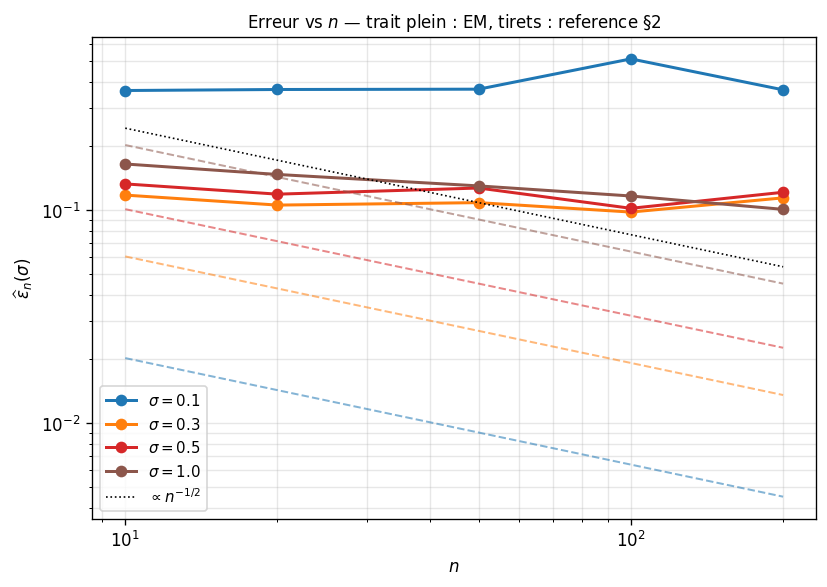

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
colors  = plt.cm.tab10(np.linspace(0, 0.55, len(sigma_list)))
n_arr   = np.array(n_list, dtype=float)

for sigma, col in zip(sigma_list, colors):
    # Courbe EM
    ax.plot(n_arr, eps_vs_n[sigma],
            'o-', color=col, lw=1.8, label=fr'$\sigma = {sigma}$')
    # Courbe de reference Section 2
    ax.plot(n_arr, [ref_error(n, sigma) for n in n_list],
            '--', color=col, lw=1.2, alpha=0.55)

# Droite-guide 1/sqrt(n)
i_mid  = len(n_list) // 2
c_guide = eps_vs_n[0.3][i_mid] * np.sqrt(n_list[i_mid])
ax.plot(n_arr, c_guide / np.sqrt(n_arr), 'k:', lw=1.0, label=r'$\propto n^{-1/2}$')

ax.set(xscale='log', yscale='log',
       xlabel=r'$n$', ylabel=r'$\widehat{\varepsilon}_n(\sigma)$')
ax.set_title(r'Erreur vs $n$ — trait plein : EM, tirets : reference §2', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('../figures/erreur_vs_n.pdf', bbox_inches='tight')
plt.show()
plt.close()

## Courbe 2 — $\varepsilon_n(\sigma)$ en fonction de $\sigma$

On fait varier $\sigma$ sur une grille linéaire `[0.05, 0.1, 0.2, 0.5, 1.0, 2.0]`
pour 4 valeurs de $n$ fixées, avec $M = 15$ répétitions par point.

In [29]:
n_list_s    = [20, 50, 100, 200]
sigma_list2 = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

np.random.seed(2)
eps_vs_sigma = {}
for n in n_list_s:
    print(f'  n = {n:3d} ...', end=' ', flush=True)
    eps_vs_sigma[n] = [estimate_eps(n, sigma, M) for sigma in sigma_list2]
    print('ok')

print('\nResultats (eps_hat) :')
print(f'{"sigma":>8}', end='')
for n in n_list_s:
    print(f'  n={n}', end='')
print()
for i, sigma in enumerate(sigma_list2):
    print(f'{sigma:8.2f}', end='')
    for n in n_list_s:
        print(f'  {eps_vs_sigma[n][i]:6.4f}', end='')
    print()

  n =  20 ... ok
  n =  50 ... ok
  n = 100 ... ok
  n = 200 ... ok

Resultats (eps_hat) :
   sigma  n=20  n=50  n=100  n=200
    0.05  0.9411  0.9736  0.9406  0.9410
    0.10  0.2718  0.3695  0.2783  0.3691
    0.20  0.1283  0.0971  0.0936  0.0973
    0.50  0.1103  0.1204  0.0977  0.1007
    1.00  0.1329  0.1285  0.1116  0.1027
    2.00  0.2060  0.1423  0.1370  0.1072


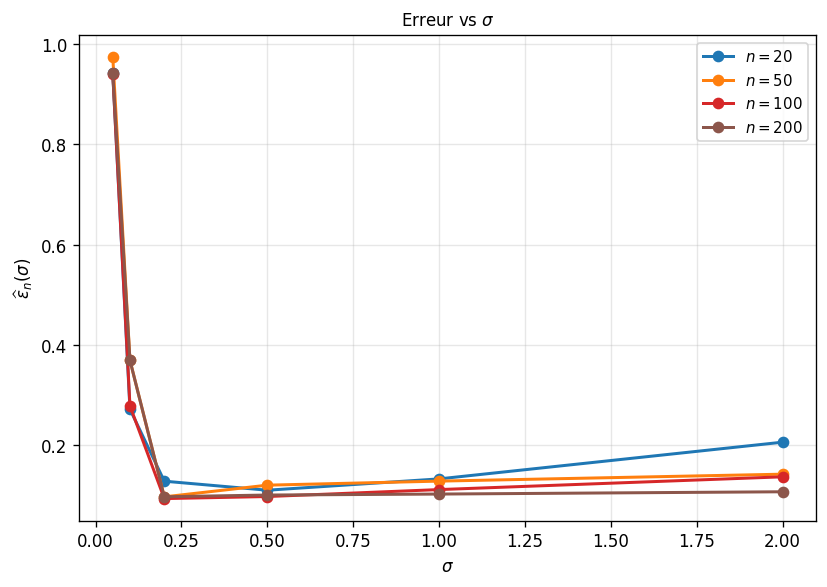

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
colors2 = plt.cm.tab10(np.linspace(0, 0.55, len(n_list_s)))

for n, col in zip(n_list_s, colors2):
    ax.plot(sigma_list2, eps_vs_sigma[n],
            'o-', color=col, lw=1.8, label=fr'$n = {n}$')

ax.set(xlabel=r'$\sigma$', ylabel=r'$\widehat{\varepsilon}_n(\sigma)$')
ax.set_title(r'Erreur vs $\sigma$', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/erreur_vs_sigma.pdf', bbox_inches='tight')
plt.show()
plt.close()